# Explainable Credit Risk Assessment

## 1. Load the Data
- We will bring in the loan applicant data.
- This data has details like income, age, and loan amount.
- It also tells us who repaid and who defaulted.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [52]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA)
- Here we simply look at the data before touching it.
- We want to understand it first, then work on it.

### Basic info about the data
- Check how many rows and columns we have.
- Check the data type of each column.

In [55]:
df.shape

(32581, 12)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [57]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Missing values
- Find out which columns have empty or missing values.
- This tells us where we may need to fix things later.

In [59]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Target balance
- Check how many people defaulted vs how many repaid.
- This tells us if our data is balanced or imbalanced.

In [61]:
df['loan_status'].unique()

array([1, 0], dtype=int64)

In [62]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

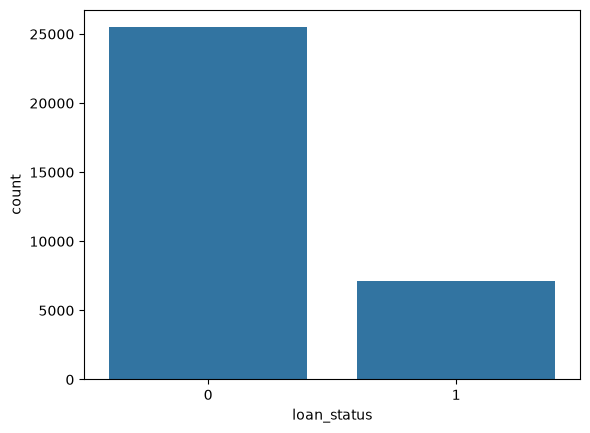

In [63]:
sns.countplot(x='loan_status', data=df)

### Outlier check
- Look for values that seem impossible, like age 144.
- These are signs of bad data entries.

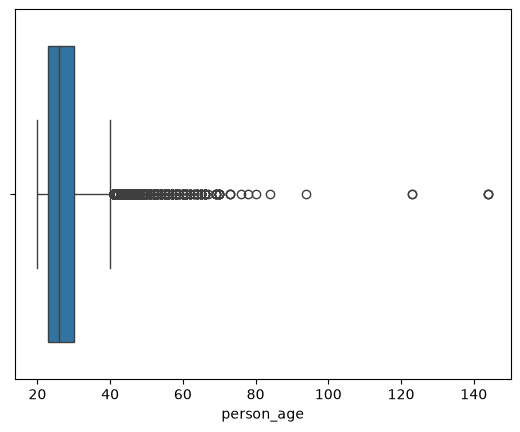

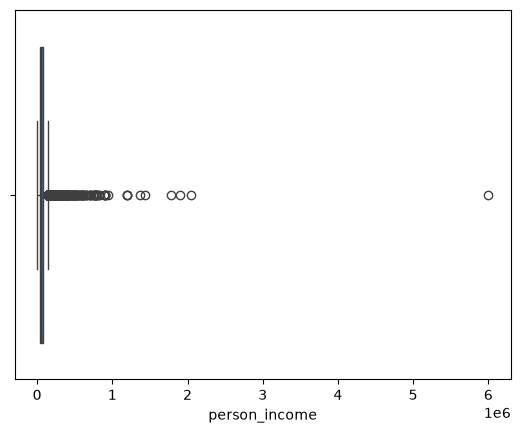

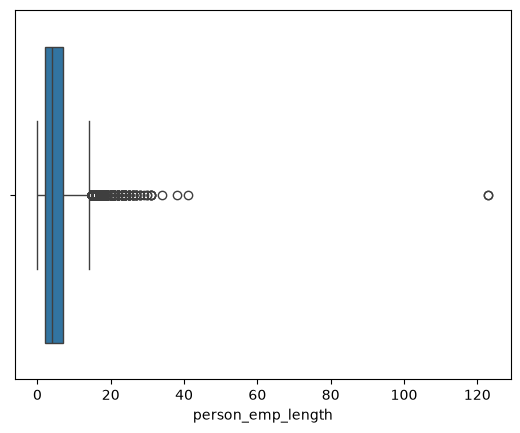

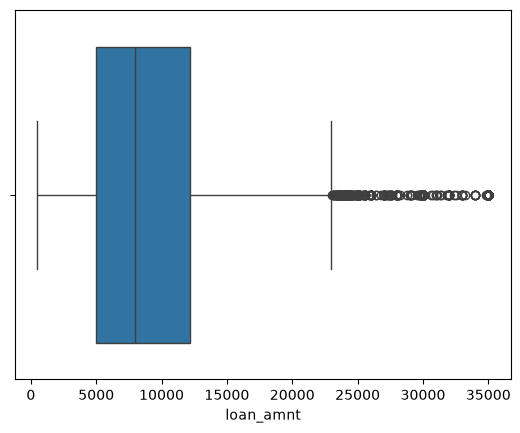

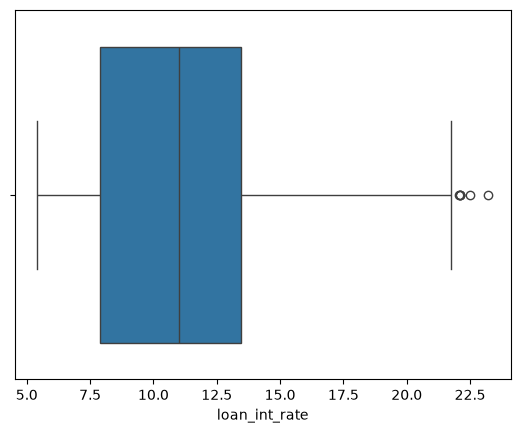

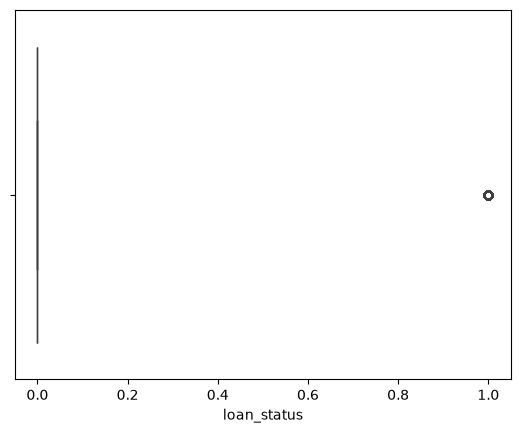

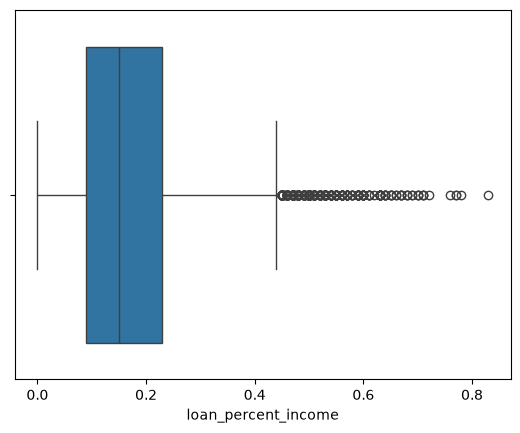

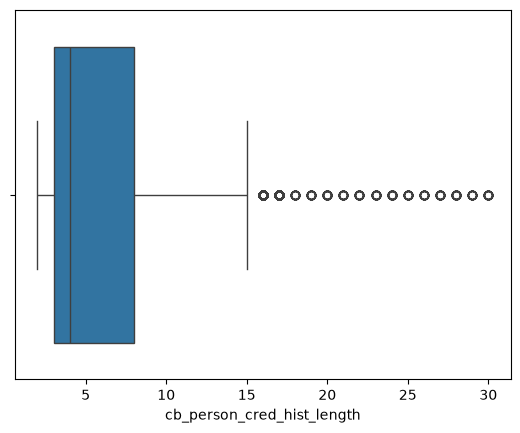

In [65]:
num_cols = df.select_dtypes(include='number').columns

for i in num_cols:
  sns.boxplot(x=df[i])
  plt.show()



In [66]:
(df['person_age'] > 100).sum()

5

In [67]:
(df['person_emp_length'] > 60).sum()

2

### Correlation check
- See how strongly features are related to each other.
- This helps us spot repeated or linked information.

In [69]:
corr = df.corr(numeric_only=True)
corr

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


<Axes: >

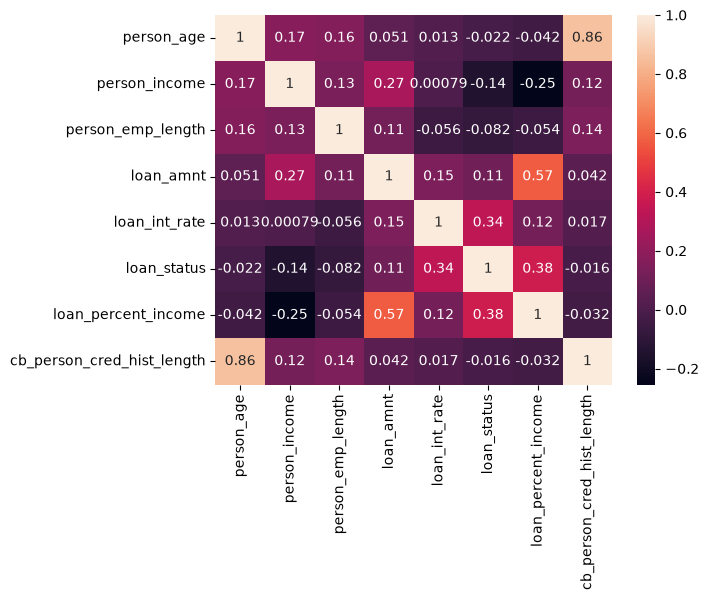

In [70]:
sns.heatmap(corr, annot=True)

## 3. Data Validation & Outlier Handling
- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove rows with zero or negative income and loan amount.
- We check if the interest rate looks realistic.
- We also flag rows where numbers don't add up correctly.

In [72]:
df_copy = df.copy()
print(f"Original Rows: {df_copy.shape[0]}")

Original Rows: 32581


In [73]:
# remove duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

Rows after removing duplicates : 32416


In [74]:
# Remove age below 18 or below 100
df_copy = df_copy[df['person_age'] >= 18]
df_copy = df_copy[df['person_age'] <= 100]

In [75]:
#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

In [76]:
#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

In [77]:
#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Loan intreset rate range from (min: 5.42 and max: 23.22)


In [78]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 4. Features, Target & Train-Test Split
- We separate the data into input features and the target.
- The target is whether the applicant defaulted or not.
- We split the data into a training part and a testing part.
- The model learns from the training part only.

In [80]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [82]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance
- Very few people actually default in this data.
- If we ignore this, the model may just favor the majority class.
- We give more importance to the minority class during training.
- This helps the model actually learn to spot defaulters.

In [84]:
# 0 -> no loan
# 1 -> approved loan

# y_train.value_counts()

neg, pos = np.bincount(y_train)
scale_weigths = neg/pos

In [85]:
scale_weigths

3.6312213039485766

## 6. Data Preprocessing — Pipelines & Column Transformer
- Raw data is not ready for a model directly.
- We need to prepare numeric and text columns differently.
- We will build a Pipeline for each model.
- We will use ColumnTransformer to apply different steps to different columns.

### Preprocessing for Logistic Regression
- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [88]:
from sklearn import preprocessing
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline for  num_cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),

        # Pipieline for cat_cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Misiing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

### Preprocessing for XGBoost
- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [90]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        # Pipeline for  num_cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), num_cols),

        # Pipieline for cat_cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Misiing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

## 7. Evaluation Helper Function
- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [92]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def eval_model(model_name, model, X, y, threshold=None):
  pred_prob = model.predict_proba(X)[:,1]

  if threshold:
    pred = (pred_prob > threshold).astype(int)
  else:
    pred = model.predict(X)

  # Metrices
  accuracy = accuracy_score(y, pred) #Overall model's preformance
  precision = precision_score(y, pred) #When the model says 1, how oftenly is it actually 1.
  recall = recall_score(y, pred) #of the actual 1 how many did the model catches
  f1 = f1_score(y, pred) #Harmonic mean of precision and recall

  # Confusion Matrix
  cm = confusion_matrix(y, pred)
  class_report = classification_report(y, pred)

  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)

  # Plottinf confusion matrix
  sns.heatmap(cm, annot=True, fmt='d')
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()

  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y, pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()


## 8. Stratified Cross-Validation
- One single train-test split may not be reliable.
- We split the training data into five folds instead.
- Each fold keeps the same default vs repaid ratio.
- We check the model's score across all folds.

In [94]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy':'accuracy',
    'precision':'precision',
    'recall':'recall',
    'f1':'f1'
}

In [95]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_cv_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [96]:
# XGboost model
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator = 300, ma_septh=5, learning_rate=0.1,
        scale_pos_weight=scale_weigths, random_state=42
    ))
])

xgb_cv_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [97]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
ROC-AUC : 0.9421957040684067
Accuracy : 0.9163262634444491
Precision : 0.8205265424963649
Recall : 0.784573002754821
F1 : 0.8019095677688715



## 9. Baseline Model — Logistic Regression
- We start with a simple model first.
- This becomes our benchmark to beat.
- We train it and check its score on the test data.

In [99]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [100]:
#Evaluate the Logistic Model.

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



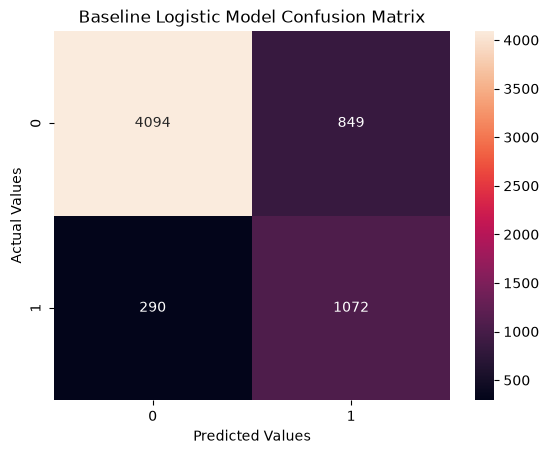

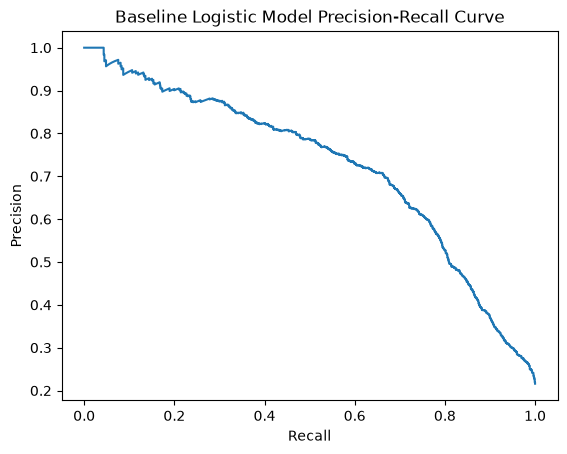

In [101]:
eval_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

## 10. XGBoost Hyperparameter Tuning
- Now we move to a stronger model, XGBoost.
- A model has many settings called hyperparameters.
- We search for the best combination of these settings.
- We use cross-validation while searching, so the result is reliable.

In [103]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1, scale_pos_weight=scale_weigths, random_state=42))
])

xg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [104]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150,600),
    "classifier__max_depth": randint(3,9),
    "classifier__learning_rate": uniform(0.01,0.5),
    "classifier__subsample": uniform(0.6, 0.4), #Rows sampling
    "classifier__colsample_bytree": uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1,10),
    "classifier__gamma": uniform(0, 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [105]:
%%time
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
CPU times: total: 54.7 s
Wall time: 2min 37s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....0016C352D9A60>, 'classifier__gamma': <scipy.stats....0016C35BC0680>, 'classifier__learning_rate': <scipy.stats....0016C352DB6B0>, 'classifier__max_depth': <scipy.stats....0016C35BC1FD0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index

In [106]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [107]:
random_search.best_params_

{'classifier__colsample_bytree': 0.7860587930454352,
 'classifier__gamma': 2.0408506827689,
 'classifier__learning_rate': 0.025573291413891912,
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 577,
 'classifier__subsample': 0.8434506538321341}

## 11. Compare Both Models Side by Side
- We now compare Logistic Regression and XGBoost.
- We look at their scores together in one table.
- This helps us pick the better performing model.

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



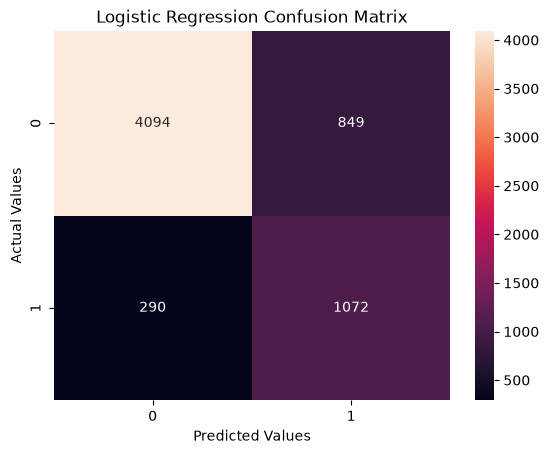

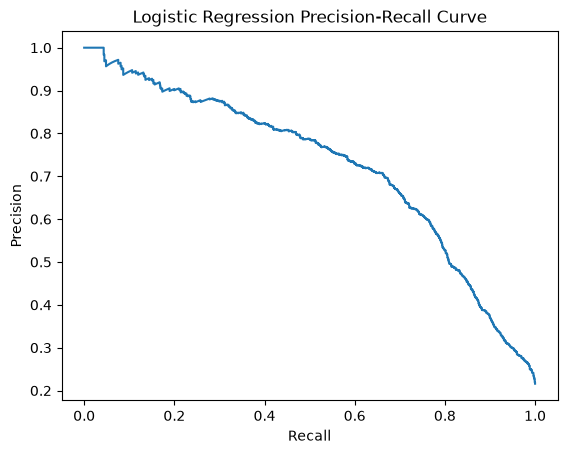

In [109]:
eval_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy : 0.93
Precision : 0.86
Recall : 0.79
F1 : 0.83

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4943
           1       0.86      0.79      0.83      1362

    accuracy                           0.93      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.93      0.93      0.93      6305



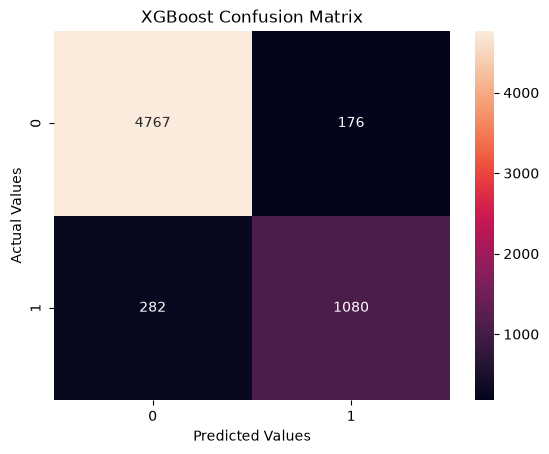

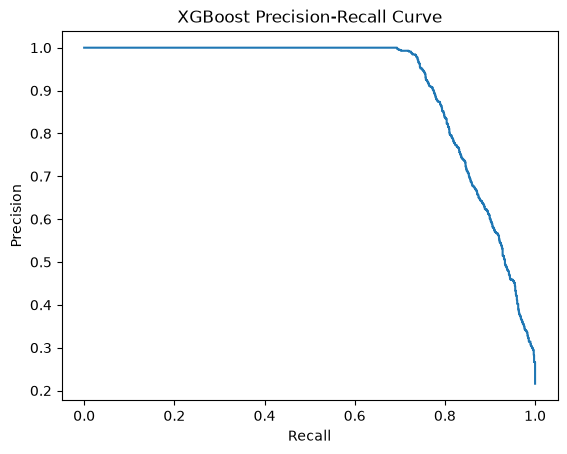

In [110]:
#Passing the XGBoost model after performing Hyperparameter Tuning
eval_model("XGBoost", random_search, X_test, y_test)

## 12. Optimizing the Classification Threshold
- The model gives a probability, not a direct yes or no.
- We decide a cut-off point to turn it into a decision.
- We check different cut-off points and pick the best one.

XGBoost Metrics:
Used Threshold : 1.00
Accuracy : 0.78
Precision : 0.00
Recall : 0.00
F1 : 0.00

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



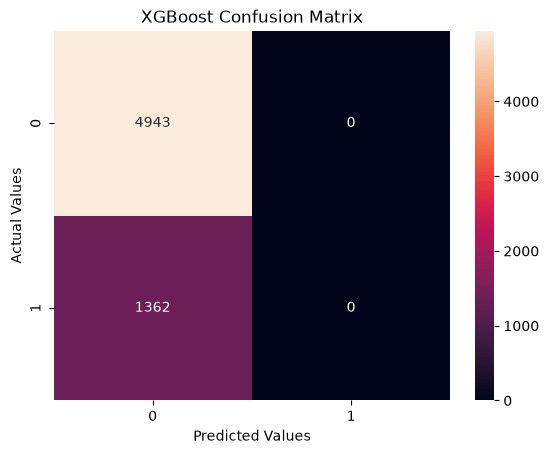

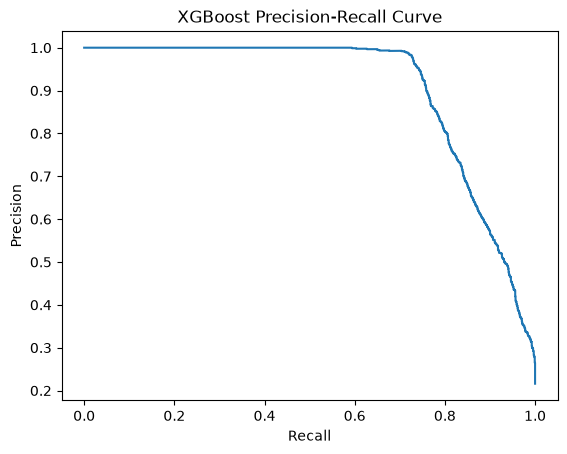

In [112]:
# Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:,1]

# For each threshold calculate Precision and Recall
precision, recall, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 score for each threshold
f1 = 2 * (precision-recall) / (precision + recall + 1e-9)

# Get the threshold that produces the highest f1-score
best_idx = np.argmax(f1[:-1])
best_threshold = thresholds[best_idx]

# Evaluate the XGBoost model using that threshold.
eval_model("XGBoost", xg_model, X_test, y_test, best_threshold)

## 13. Probability Calibration
- Sometimes a model's probability doesn't mean what it says.
- For example, 30% risk should truly mean a 30% chance.
- We check this with a calibration plot.
- We fix it if the probabilities are off.

In [114]:
print(
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""
)


Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature



In [115]:
# 1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    # xg_model,
    best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0016C3546F1D0>, <

In [116]:
# 2. Get Probabilities
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]
# uncalibrated, calibrated

In [117]:
# 3. Create calibartion curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [118]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

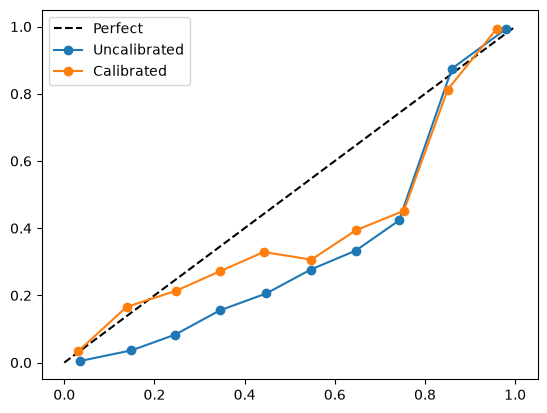

In [119]:
# 4. Plot
plt.plot([0,1], [0,1], 'k--', label="Perfect")

plt.plot(predicted_uncal, actual_uncal, 'o-', label='Uncalibrated')

plt.plot(predicted_cal, actual_cal, 'o-', label='Calibrated')

plt.legend();

## 14. SHAP Interpretation — Global & Local
- SHAP helps us understand why the model makes a decision.
- It is a way of explaining a "black box" model.

In [121]:
#1. Install SHAP if not exists
!pip install shap
import shap

   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.6 MB 186.4 kB/s eta 0:01:21
   - -------------------------------------- 0.5/15.6 MB 186.4 kB/s eta 0:01:21
  

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.5 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [122]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

In [123]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [124]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [125]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [126]:
#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [127]:
#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

### Global explanation
- This shows which features matter most overall.
- It also shows if a feature increases or decreases risk.

In [ ]:
shap.summary_plot(shap_values, X_test_df)

### Local explanation
- This shows why one specific applicant got their score.
- It breaks the score down feature by feature.

In [ ]:
import random
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index= random.randint(0, X_test_df.shape[0])
print("Selected row: ", row_index)

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## 15. Analyzing False Positives & False Negatives
- The model will not be perfect.
- False positives are safe people wrongly marked risky.
- False negatives are risky people wrongly marked safe.
- We study these cases to understand where the model struggles.

In [ ]:
#Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [ ]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [ ]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

In [ ]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

In [ ]:
#False Negative > False Positive

## 16. Save the Final Model
- Once we are happy with the model, we save it.
- We also save the settings it needs, like the chosen threshold.
- This saved file can now be used in a real application.

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get probabilities from the CALIBRATED model, not the old xg_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Re-run the same threshold search, now on the correct probability scale
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("New threshold:", best_threshold)

In [ ]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

In [ ]:
joblib.dump(best_threshold, "best_threshold.pkl")